In [1]:
#导入相关依赖库
import  os
import numpy as np
from matplotlib import pyplot as plt
import mindspore as ms
#nn中有各种神经网络层如：Dense，ReLu
#context模块用于设置实验环境和实验设备
#load_checkpoint, load_param_into_net将模型参数存入parameter的字典中，并将参数加载到网络中
from mindspore import nn, context, load_checkpoint, load_param_into_net, Tensor
#dataset模块用于处理数据形成数据集
import mindspore.dataset as ds
#transforms模块用于转换数据类型
#vision模块用于转换图像，这是一个基于opencv的高级API
from mindspore.dataset import transforms, vision
#Model用于创建模型对象，完成网络搭建和编译，并用于训练和评估;
#LossMonitor可以在训练过程中返回LOSS值作为监控指标；
#导入Accuracy作为评价指标。
from mindspore.train import Model, LossMonitor, Accuracy, CheckpointConfig, ModelCheckpoint


/usr/local/Ascend/ascend-toolkit/7.0.RC1/python/site-packages/tbe/tvm/contrib/ccec.py:766: DeprecationWarning: invalid escape sequence \L
  if not dirpath.find("AppData\Local\Temp"):
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:222: DeprecationWarning: invalid escape sequence \B
  """
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:140: DeprecationWarning: invalid escape sequence \c
  """
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, 

In [2]:
# 定义训练集和测试集路径
DATA_DIR_TRAIN = "./train" # 训练集信息
DATA_DIR_TEST = "./test" # 测试集信息

In [3]:
#数据集处理函数
def create_dataset(training=True, batch_size=64, resize=(32,32),rescale=1/255, shift=-0.5):
    ds = ms.dataset.MnistDataset(DATA_DIR_TRAIN if training else DATA_DIR_TEST, shuffle=True)

    #定义改变形状、归一化和更改图片维度的操作。
    trans_transform = [
        vision.Resize(resize),
        # vision.RandomHorizontalFlip(prob=0.5),
        # vision.RandomRotation(10),  # 旋转角度范围 ±10°
        vision.Rescale(rescale, shift),
        vision.HWC2CHW(),
    ]

    label_transform = transforms.TypeCast(ms.int32)

    # 利用map操作对原数据集进行调整
    ds = ds.map(operations=trans_transform, input_columns=["image"])
    ds = ds.map(operations=label_transform, input_columns=["label"])

    ds = ds.batch(batch_size, drop_remainder=True)

    return ds


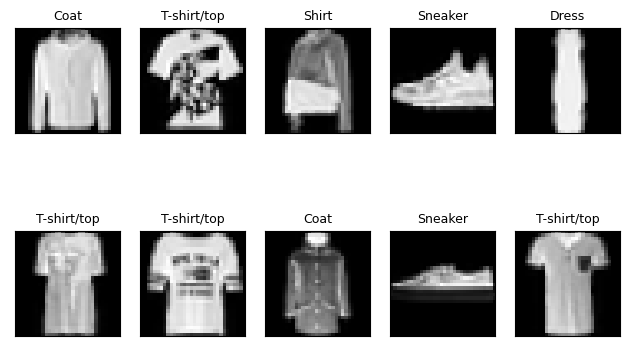

In [15]:
# 标签映射表：将数字转为英文服装名
label_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# 获取一个 batch 的训练数据
dataset_show = create_dataset(training=True)
data = dataset_show.create_dict_iterator().__next__()
images = data['image'].asnumpy()
labels = data['label'].asnumpy()

# 显示前10张图片及其标签
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(np.squeeze(images[i]), cmap='gray')
    plt.title(label_map[int(labels[i])], fontsize=9)  # 使用英文名称作为标题
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


In [5]:
train_dataset = create_dataset(True, 64)
test_dataset = create_dataset(False, 64)

In [6]:
# for image, label in test_dataset.create_tuple_iterator():
#     print(f"Shape of image [N, C, H, W]: {image.shape} {image.dtype}")
#     print(f"Shape of label: {label.shape} {label.dtype}")
#     break

In [7]:
# 模型构建
class Network(nn.Cell):
    def __init__(self):
        super().__init__()
        # 添加卷积层以提取空间特征
        self.conv_layers = nn.SequentialCell(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, pad_mode='pad', padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, pad_mode='pad', padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, pad_mode='pad', padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 最终特征图尺寸：4x4
        )

        self.flatten = nn.Flatten()
        self.dense_relu_sequential = nn.SequentialCell(
            nn.Dropout(keep_prob=0.5),                   # Dropout 层
            nn.Dense(128 * 4 * 4, 128),                  # 可加一层中间全连接
            nn.ReLU(),
            nn.Dense(128, 10),                           # 输出10类
        )


    def construct(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        logits = self.dense_relu_sequential(x)
        return logits
model = Network()
# print(model)


[WARNING] DEVICE(133173,ffff7f95f0b0,python):2025-07-16-20:33:05.393.515 [mindspore/ccsrc/plugin/device/ascend/hal/device/ascend_runtime_manager.cc:46] GetAscendRuntime] No ascend runtime creator for AscendVM with device id 0
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if _ is not 1:
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if _ is not 1:
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if _ is not 1:
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: Sy

Network<
  (conv_layers): SequentialCell<
    (0): Conv2d<input_channels=1, output_channels=32, kernel_size=(3, 3), stride=(1, 1), pad_mode=pad, padding=1, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xfffed1a37280>, bias_init=None, format=NCHW>
    (1): BatchNorm2d<num_features=32, eps=1e-05, momentum=0.9, gamma=Parameter (name=conv_layers.1.gamma, shape=(32,), dtype=Float32, requires_grad=True), beta=Parameter (name=conv_layers.1.beta, shape=(32,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=conv_layers.1.moving_mean, shape=(32,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=conv_layers.1.moving_variance, shape=(32,), dtype=Float32, requires_grad=False)>
    (2): ReLU<>
    (3): MaxPool2d<kernel_size=2, stride=2, pad_mode=VALID>
    (4): Conv2d<input_channels=32, output_channels=64, kernel_size=(3, 3), stride=(1, 1), pad_mode=pad, padding=1, dilation=(1, 1), group=1, has_bias=False

In [16]:
# 构建损失函数和优化器
# loss_fn = nn.CrossEntropyLoss()
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
optimizer = nn.SGD(model.trainable_params(), 1e-2)

# 1. 定义前递函数
def forward_fn(data, label):
    logits = model(data)
    loss = loss_fn(logits, label)
    return loss, logits

# 2. 梯度函数
grad_fn = ms.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=True)

# 3. 定义单步训练
def train_step(data, label):
    (loss, _), grads = grad_fn(data, label)
    optimizer(grads)
    return loss

def train(model, dataset):
    size = dataset.get_dataset_size()
    model.set_train()
    for batch, (data, label) in enumerate(dataset.create_tuple_iterator()):
        loss = train_step(data, label)
        
        if batch % 100 == 0:
            loss_val = loss.asnumpy()
            current = batch
            # 使用颜色编码：绿色 (< 0.5), 黄色 (0.5-1.0), 红色 (> 1.0)
            color = "\033[32m" if loss_val < 0.5 else "\033[33m" if loss_val < 1.0 else "\033[31m"
            reset_color = "\033[0m"
            print(f"+---------------------------+")
            print(f"| Batch Progress            |")
            print(f"+------------+------+-------+")
            print(f"| Batch      | {current:3d} | {size:3d} |")
            print(f"+------------+------+-------+")
            print(f"| Loss       | {color}{loss_val:>6.4f}{reset_color} |")
            print(f"+------------+------+-------+")




In [9]:
def test(model, dataset, loss_fn):
    num_batches = dataset.get_dataset_size()
    model.set_train(False)
    total, test_loss, correct = 0, 0, 0
    for data, label in dataset.create_tuple_iterator():
        pred = model(data)
        total += len(data)
        test_loss += loss_fn(pred, label).asnumpy()
        correct += (pred.argmax(1) == label).asnumpy().sum()
    test_loss /= num_batches
    correct /= total
    # 使用颜色编码：绿色 (> 90%), 黄色 (80-90%), 红色 (< 80%)
    color_acc = "\033[32m" if correct * 100 > 90 else "\033[33m" if correct * 100 > 80 else "\033[31m"
    color_loss = "\033[32m" if test_loss < 0.3 else "\033[33m" if test_loss < 0.5 else "\033[31m"
    reset_color = "\033[0m"
    print(f"\n+--------------------------------+")
    print(f"| Test Results                   |")
    print(f"+------------+---------+---------+")
    print(f"| Metric     | Value   |         |")
    print(f"+------------+---------+---------+")
    print(f"| Accuracy   | {color_acc}{correct*100:>5.1f}%{reset_color} |")
    print(f"| Avg Loss   | {color_loss}{test_loss:>7.4f}{reset_color} |")
    print(f"+------------+---------+---------+")


In [17]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(model, train_dataset)
    test(model, test_dataset, loss_fn)
print("完成!")


Epoch 1
-------------------------------
+---------------------------+
| Batch Progress            |
+------------+------+-------+
| Batch      |   0 | 937 |
+------------+------+-------+
| Loss       | 0.2867 |
+------------+------+-------+
+---------------------------+
| Batch Progress            |
+------------+------+-------+
| Batch      | 100 | 937 |
+------------+------+-------+
| Loss       | 0.2597 |
+------------+------+-------+
+---------------------------+
| Batch Progress            |
+------------+------+-------+
| Batch      | 200 | 937 |
+------------+------+-------+
| Loss       | 0.1399 |
+------------+------+-------+
+---------------------------+
| Batch Progress            |
+------------+------+-------+
| Batch      | 300 | 937 |
+------------+------+-------+
| Loss       | 0.1510 |
+------------+------+-------+
+---------------------------+
| Batch Progress            |
+------------+------+-------+
| Batch      | 400 | 937 |
+------------+------+-------+
| Loss   

In [11]:
# 保存模型
ms.save_checkpoint(model, "clothes_model.ckpt")
print("Saved Model to clothes_model.ckpt")


Saved Model to clothes_model.ckpt


In [12]:
# 实例化一个随机初始化的模型
model = Network()
# 加载之前保存的模型
param_dict = ms.load_checkpoint("clothes_model.ckpt")
param_not_load, _ = ms.load_param_into_net(model, param_dict)
# print(param_not_load)


[WARNING] ME(133173:281472822276272,MainProcess):2025-07-16-20:35:42.208.135 [mindspore/nn/layer/basic.py:173] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Predicted: "['7 (Sneaker)', '6 (Shirt)', '9 (Ankle boot)', '2 (Pullover)', '2 (Pullover)', '5 (Sandal)', '8 (Bag)', '4 (Coat)', '8 (Bag)', '9 (Ankle boot)']", Actual: "['7 (Sneaker)', '0 (T-shirt/top)', '9 (Ankle boot)', '6 (Shirt)', '2 (Pullover)', '5 (Sandal)', '8 (Bag)', '4 (Coat)', '8 (Bag)', '9 (Ankle boot)']"


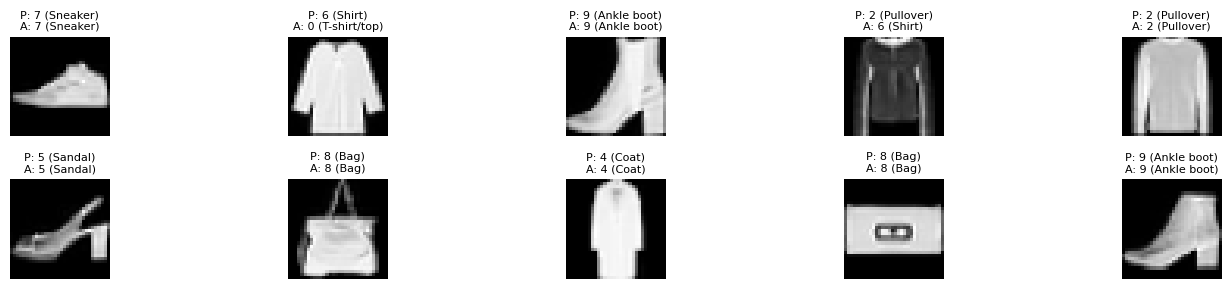

In [20]:
model.set_train(False)
for data, label in test_dataset:
    pred = model(data)
    predicted = pred.argmax(1)
    # Get the first 10 predictions and actual labels with their corresponding names
    pred_names = [f"{i} ({['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'][i]})" for i in predicted[:10]]
    actual_names = [f"{i} ({['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'][i]})" for i in label[:10]]
    print(f'Predicted: "{pred_names}", Actual: "{actual_names}"')
    # Visualize the first 10 images with predictions
    plt.figure(figsize=(15, 3))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(np.squeeze(data[i].asnumpy()), cmap='gray')
        plt.title(f'P: {pred_names[i]}\nA: {actual_names[i]}', fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    break
